# Generative Adversarial Networks (GANs)

In this lecture, we will discuss generative adversarial networks (GANs).

## What is a Generative Adversarial Network?

Neural networks (NNs) were devised as prediction and classification models. They are powerful, non-linear optimizers which can be trained to evolve their inner parameters (neuron weights) to fit the training data. This will enable the NN to predict and classify unknown data of the same kind.

We all know how impressive the data approximations of neural networks, in which ‘data‘ can mean just about anything, can be. However, the features of such algorithms also suggest some of their drawbacks, such as:

- Neural networks need labelled data to be trained properly
- Worse, they need a lot of labelled data
- Worse still, we generally have no idea what the contents of a neuron actually do, except in some special cases

Intrinsically, neural networks are supervised algorithms. Nonetheless, some of their variants work perfectly well as unsupervised algorithms. These can be trained on any kind of data, without requiring the ‘label‘ usually attached to enable the network to differentiate known things from unknown things.

The GAN paradigm offers another interesting unsupervised setting for neural networks to play in, and is decribed briefly below.

A GAN aims at generating new data via networks deliberately set up in competition with each other in order to achieve this goal. A GAN is always split into two components – two neural (usually deep) networks. 


- The **generator** learns to generate plausible data. The generated instances become negative training examples for the discriminator.
- The **discriminator** learns to distinguish the generator's fake data from real data. The discriminator penalizes the generator for producing implausible results.

![](https://developers.google.com/static/machine-learning/gan/images/gan_diagram.svg)

*Image from Google for Developers*

## GAN for images

Due to the training time limitation, I will not run this part. Please have a look at it.

In [1]:
import torch
from torch import nn

import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [2]:
device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

The function has two parts:

transforms.ToTensor() converts the data to a PyTorch tensor.
transforms.Normalize() converts the range of the tensor coefficients.

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

Now you can load the training data using torchvision.datasets.MNIST and perform the conversions using transform:

In [4]:
train_set = torchvision.datasets.MNIST(
    root=".", train=True, download=True, transform=transform
)

The argument download=True ensures that the first time you run the above code, the MNIST dataset will be downloaded and stored in the current directory, as indicated by the argument root.

Now that you’ve created train_set, you can create the data loader as you did before:

In [5]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)


You can use Matplotlib to plot some samples of the training data. To improve the visualization, you can use cmap=gray_r to reverse the color map and plot the digits in black over a white background:

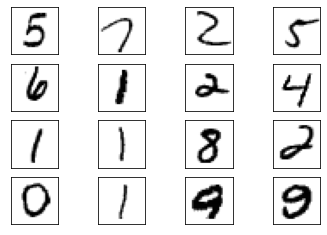

In [6]:
real_samples, mnist_labels = next(iter(train_loader))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

### Implementing the Discriminator and the Generator

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output

In [11]:
discriminator = Discriminator().to(device=device)
generator = Generator().to(device=device)

lr = 0.0001
num_epochs = 80
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

I set the number of epochs to 4 to reduce the training time. To obtain better result, you should set the number of epochs to a large number, for example, 50.

The training loop is very similar to the one you used in the previous example. In the highlighted lines, you send the training data to device to use the GPU if available:

In [12]:
for epoch in range(num_epochs):
    for n, (real_samples, mnist_labels) in enumerate(train_loader):
        # Data for training the discriminator
        real_samples = real_samples.to(device=device)
        real_samples_labels = torch.ones((batch_size, 1)).to(
            device=device
        )
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1)).to(
            device=device
        )
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Training the discriminator
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(
            output_discriminator, all_samples_labels
        )
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )

        # Training the generator
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Show loss
        if n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.5076758861541748
Epoch: 0 Loss G.: 0.5745351910591125
Epoch: 1 Loss D.: 0.010244891047477722
Epoch: 1 Loss G.: 12.025121688842773
Epoch: 2 Loss D.: 0.0345887765288353
Epoch: 2 Loss G.: 4.528762340545654
Epoch: 3 Loss D.: 0.004303995054215193
Epoch: 3 Loss G.: 8.277058601379395
Epoch: 4 Loss D.: 0.03115585446357727
Epoch: 4 Loss G.: 10.051198959350586
Epoch: 5 Loss D.: 0.1843542605638504
Epoch: 5 Loss G.: 3.7628495693206787
Epoch: 6 Loss D.: 0.3152245581150055
Epoch: 6 Loss G.: 3.533991813659668
Epoch: 7 Loss D.: 0.28132978081703186
Epoch: 7 Loss G.: 2.562283992767334
Epoch: 8 Loss D.: 0.2626478672027588
Epoch: 8 Loss G.: 3.065659523010254
Epoch: 9 Loss D.: 0.4031698405742645
Epoch: 9 Loss G.: 1.852407455444336
Epoch: 10 Loss D.: 0.3681901693344116
Epoch: 10 Loss G.: 1.6404417753219604
Epoch: 11 Loss D.: 0.48298391699790955
Epoch: 11 Loss G.: 1.53789484500885
Epoch: 12 Loss D.: 0.41222381591796875
Epoch: 12 Loss G.: 2.038642406463623
Epoch: 13 Loss D.: 0.410813033580

KeyboardInterrupt: 

Since this example features more complex models, the training may take a bit more time. After it finishes, you can check the results by generating some samples of handwritten digits.

In [13]:
latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

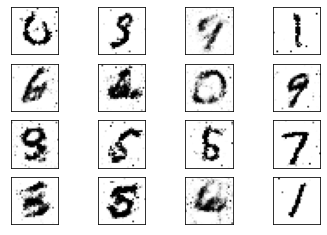

In [14]:
generated_samples = generated_samples.cpu().detach()
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

## GAN for signal processing

Instead of a collection of images, I’ll produce a description of the curves I am interested in: sinusoids may be mathematically described as the graph of functions

$$ a \sin(bx+c) $$

where a, b, c are parameters which determine the height, frequency and phase of the curve. Some examples of such curves are plotted in the following picture, produced via a Python snippet.

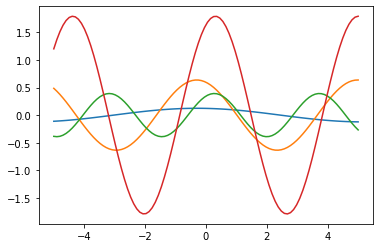

In [15]:
import matplotlib.pyplot as plt
import numpy as np
 
X_MIN = -5.0
X_MAX = 5.0
SAMPLE_LEN = 100
X_COORDS = np.linspace(X_MIN , X_MAX, SAMPLE_LEN)
fig, axis = plt.subplots(1, 1)
for i in range(4):
    axis.plot(X_COORDS, np.random.uniform(0.1,2.0)*np.sin(np.random.uniform(0.2,2.0)*X_COORDS + np.random.uniform(2)))

We want our GAN to generate curves with this sort of form. To keep things simple we consider a=1 and let b∈[1/2,2] and c∈[0,π].

First, we define some constants and produce a dataset of such curves.

### Generate dataset

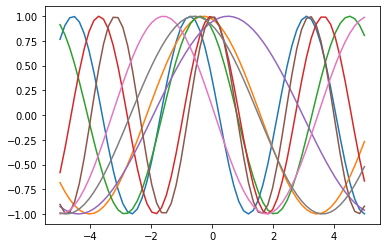

In [16]:
import numpy as np
import matplotlib.pyplot as plt

sample_len = 64       # number N of points where a curve is sampled
sample_size = 300     # number of curves in the training set
x_min = -5.0          # least ordinate where to sample
x_max = 5.0           # last ordinate where to sample

# The set of coordinates over which curves are sampled
x_coords = np.linspace(x_min , x_max, sample_len)

# The training set
sample = np.zeros((sample_size, sample_len))
for i in range(sample_size):
    b = np.random.uniform(0.5, 2.0)
    c = np.random.uniform(np.pi)
    sample[i] = np.array([np.sin(b*x + c) for x in x_coords])

# we plot the first 8 curves
fig, axis = plt.subplots(1, 1)
for i in range(8):
    axis.plot(x_coords, sample[i])

### Create discriminator and generator

In [32]:
discriminator = tf.keras.models.Sequential()
discriminator.add(tf.keras.layers.Dense(sample_len, activation="relu"))
discriminator.add(tf.keras.layers.Dropout(0.4))
discriminator.add(tf.keras.layers.Dense(sample_len, activation="relu"))
discriminator.add(tf.keras.layers.Dropout(0.4))
discriminator.add(tf.keras.layers.Dense(1, activation = "sigmoid"))
discriminator.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [33]:
LEAKY_RELU = tf.keras.layers.LeakyReLU(0.2)   # Empirical hyperparameter
generator = Sequential()
generator.add(tf.keras.layers.Dense(sample_len))
generator.add(LEAKY_RELU)
generator.add(tf.keras.layers.Dense(512))
generator.add(LEAKY_RELU)
generator.add(tf.keras.layers.Dense(sample_len, activation = "tanh"))
generator.compile(optimizer = "adam", loss = "mse", metrics = ["accuracy"])

In [35]:
gan = tf.keras.models.Sequential()
gan.add(generator)
gan.add(discriminator)
gan.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout, LeakyReLU

discriminator = tf.keras.models.Sequential([

    tf.keras.layers.Dense(sample_len, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(sample_len, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
discriminator.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])


generator = tf.keras.models.Sequential([

    tf.keras.layers.Dense(sample_len, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation="tanh"),
])
discriminator.compile(optimizer = "adam", loss = "mse", metrics = ["accuracy"])


gan = tf.keras.models.Sequential([generator, discriminator])
gan.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

KeyboardInterrupt: 

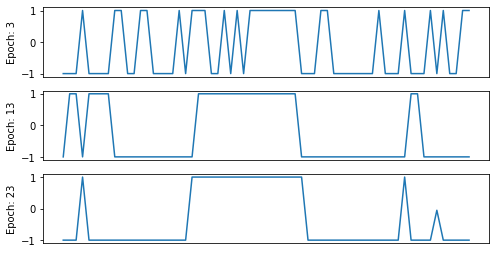

In [37]:
epochs = 64
batch = 64
 
noise = np.random.uniform(x_min, x_max, size = (sample_size, sample_len))
ones = np.ones((sample_size))
zeros = np.zeros((sample_size))

fig = plt.figure(figsize = (8, 12))
ax_index = 1
for e in range(epochs):
    for k in range(sample_size//batch):
        # Addestra il discriminatore a riconoscere le sinusoidi vere da quelle prodotte dal generatore
        n = np.random.randint(0, sample_size, size = batch)
        # Ora prepara un batch di training record per il discriminatore
        p = generator.predict(noise[n])
        x = np.concatenate((sample[n], p))
        y = np.concatenate((ones[n], zeros[n]))
        d_result = discriminator.train_on_batch(x, y)
        discriminator.trainable = False
        g_result = gan.train_on_batch(noise[n], ones[n])
        discriminator.trainable = True
    #print(f" {e:04n} |  {d_result[0]:.5f}  |  {d_result[1]:.5f} |  {g_result[0]:.5f}  |  {d_result[1]:.5f}")
    # At 3, 13, 23, ... plots the last generator prediction
    if e % 10 == 3:
        ax = fig.add_subplot(8, 1, ax_index)
        plt.plot(x_coords, p[-1])
        ax.xaxis.set_visible(False)
        plt.ylabel(f"Epoch: {e}")
        ax_index += 1
        
# Plots a curve generated by the GAN
y = generator.predict(np.random.uniform(x_min, x_max, size = (1, sample_len)))[0]
ax = fig.add_subplot(8, 1, ax_index)
plt.plot(x_coords, y)